Instructions
1. Follows this example to practice on your own
https://towardsdatascience.com/my-first-nlp-pipeline-99d24aafb773

  Data set:
https://www.kaggle.com/datasets/hijest/genre-classification-dataset-imdb?fbclid=IwAR0tHMvFy7dmPQCdif2Trf_oDJOuzqS6eoiMJM4W5wXVvzeYwAv-idruHSQ
2. Find other dataset on your own for text classification task
3. Submit your work (link to colab notebook) + dataset + 1 page pdf explanation of your work

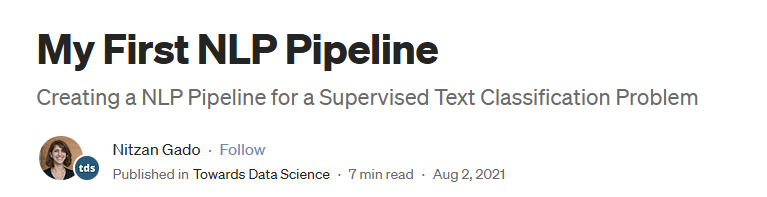

# Import pakager

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import string
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer # แปลง Text เป็น Data Back of word
from sklearn.feature_extraction.text import TfidfVectorizer # แปลง Text เป็น Data
from sklearn.naive_bayes import MultinomialNB # Algorithm1
from sklearn.tree import DecisionTreeClassifier # Algorithm2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from gensim.models import Word2Vec
import regex as re

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Load Data

In [ ]:
train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Genre Classification Dataset/train_data.txt',delimiter=':::',names=['original_title','is_drama','overview'])
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Genre Classification Dataset/test_data.txt',delimiter=':::',names=['original_title','overview'])
test_sol = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Genre Classification Dataset/test_data_solution.txt',delimiter=':::',names=['original_title','is_drama','overview'])

<ipython-input-234-cbc7fd8804ca>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Genre Classification Dataset/train_data.txt',delimiter=':::',names=['original_title','is_drama','overview'])
<ipython-input-234-cbc7fd8804ca>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Genre Classification Dataset/test_data.txt',delimiter=':::',names=['original_title','overview'])
<ipython-input-234-cbc7fd8804ca>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine d

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54214 entries, 1 to 54214
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   original_title  54214 non-null  object
 1   is_drama        54214 non-null  object
 2   overview        54214 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB


In [ ]:
train_data.overview.iloc[0]

' Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.'

In [ ]:
train_data.overview.iloc[1]

' A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.'

# Fix Bug Trim (เพราะมีผลต่อการเขียน condition)

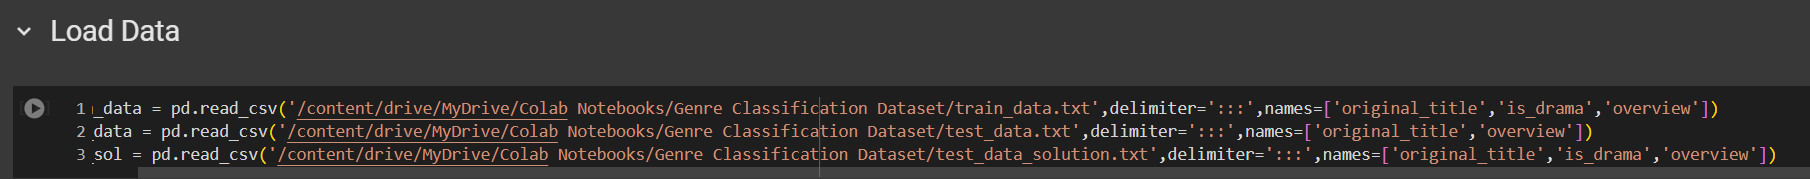

แก้ Bug Trim ตั้งแต่ตอน โหลด Data ก็ได้ โดยใส่ `' ::: '` เพื่อเป็นการตัดช่องว่างระหว่างคำ

In [ ]:
# trim data
def strip_one_space(s):
  if s.endswith(" "): s = s[:-1]
  if s.startswith(" "): s = s[1:]
  return s

In [ ]:
# Apply def trim for train data
train_data['is_drama'] = train_data['is_drama'].apply(strip_one_space)
train_data['overview'] = train_data['overview'].apply(strip_one_space)
# Apply def trim for test_sol
test_sol['is_drama'] = test_sol['is_drama'].apply(strip_one_space)
test_sol['overview'] = test_sol['overview'].apply(strip_one_space)

In [ ]:
train_data.overview.iloc[0]

'Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.'

In [ ]:
test_sol.overview.iloc[0]

"L.R. Brane loves his life - his car, his apartment, his job, but especially his girlfriend, Vespa. One day while showering, Vespa runs out of shampoo. L.R. runs across the street to a convenience store to buy some more, a quick trip of no more than a few minutes. When he returns, Vespa is gone and every trace of her existence has been wiped out. L.R.'s life becomes a tortured existence as one strange event after another occurs to confirm in his mind that a conspiracy is working against his finding Vespa."

In [ ]:
train_data.is_drama.iloc[0]

'drama'

# 1. Exploring the Data

In [ ]:
# Clean data
train_data.dropna( inplace=True) # ลบ row ที่ไม่มีข้อมูลทิ้ง
test_sol.dropna( inplace=True)

Mean overview length:  599.4524292618142
Min overview length:  41
Max overview length:  10503


<Axes: ylabel='Frequency'>

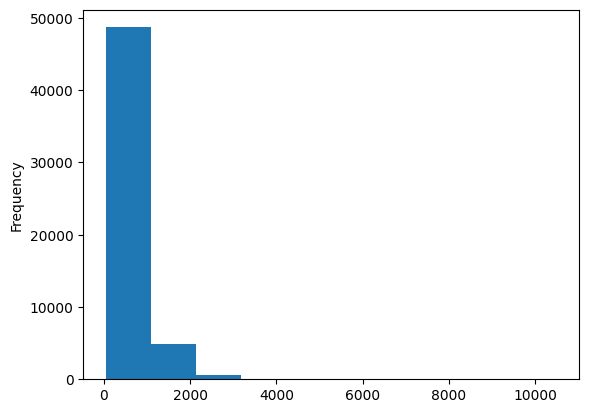

In [ ]:
# Explore data
train_data['overview_length'] = train_data['overview'].apply(len) # นับความยาวตัวอักษร
print("Mean overview length: ", train_data['overview_length'].mean()) # ค่าเฉลี่ยความยาวตัวอักษร
print("Min overview length: ", train_data['overview_length'].min()) # ความยาวตัวอักษรน้อยสุด
print("Max overview length: ", train_data['overview_length'].max()) # ความยาวตัวอักษรมากสุด
train_data['overview_length'].plot.hist() # plot Histrogram

In [ ]:
def is_drama_check(str) : # def function to create drama or not?
  if str == 'drama' :
    return 'True'
  else:
    return 'False'

In [ ]:
train_data['is_drama'] = train_data['is_drama'].apply(is_drama_check)
test_sol['is_drama'] = test_sol['is_drama'].apply(is_drama_check)

In [ ]:
train_data.head()

,original_title,is_drama,overview,overview_length
1,Oscar et la dame rose (2009),True,Listening in to a conversation between his doc...,545
2,Cupid (1997),False,A brother and sister with a past incestuous re...,183
3,"Young, Wild and Wonderful (1980)",False,As the bus empties the students for their fiel...,649
4,The Secret Sin (1915),True,To help their unemployed father make ends meet...,1081
5,The Unrecovered (2007),True,The film's title refers not only to the un-rec...,624


In [ ]:
train_data[['overview','overview_length']].sort_values(by='overview_length',ascending=True).head(10)

,overview,overview_length
52225,A buddy film set in the world of fashion.,41
48606,Documental sobre canciones de Enric Barbat.,43
51521,Documental sobre la elección de Miss Europa,43
12362,The story of the Irish National Baseball Team.,46
4755,Details of the plot are being kept under wraps.,47
47520,Documental sobre la Estación de Chamartín (Mad...,51
50997,Documental sobre la evolución de la Marina Esp...,52
23670,Documental rodado sobre fotografías fijas de V...,52
48900,Caribbean performance of British jazz group Ac...,62
46111,Documental sobre arquitectura y sobre la histo...,62


## Word cloud

In [ ]:
text = list(train_data[train_data["is_drama"] == 'True'].overview.values) # สร้าง list review หนัง
text[:5]

['Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.',
 "To help their unemployed father make ends meet, Edith and her twin sister Grace work as seamstresses . An invalid, Grace falls prey to the temptations of Chinatown opium and becomes an addict, a condition worsened by a misguided physician who prescribes morphine to ease her pain. When their father strikes oil, the family enjoys a new prosperity and the sisters meet the eligible Jack Herron, a fellow oil prospector. To Grace's shock, Jack falls 

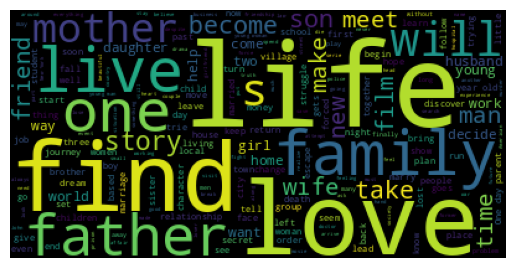

In [ ]:
# สร้าง Word cloud
wordcloud = WordCloud(stopwords=STOPWORDS).generate(str(text)) # ตัดคำพวก a, the,... เพื่อ show คำที่มีความหมาย
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

อธิบายภาพ ก็คือภาพยนตร์ drama จะเกี่ยวกับ life/family/love/....

# 2. Clean Data for Train model

Mean overview length:  565.0028306838632
Min overview length:  51
Max overview length:  1999


<Axes: ylabel='Frequency'>

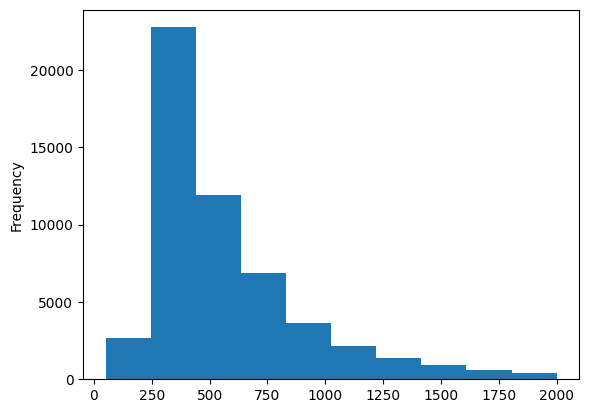

In [ ]:
train_data = train_data.loc[train_data["overview_length"] > 50] # filter เฉพาะความยาวตัวอักษร > 50
train_data = train_data.loc[train_data["overview_length"] < 2000] # filter เฉพาะความยาวตัวอักษร < 2000
print("Mean overview length: ", train_data['overview_length'].mean()) # ค่าเฉลี่ยความยาวตัวอักษร
print("Min overview length: ", train_data['overview_length'].min()) # ความยาวตัวอักษรน้อยสุด
print("Max overview length: ", train_data['overview_length'].max()) # ความยาวตัวอักษรมากสุด
train_data.overview_length.plot.hist()

##  remove punctuation เครื่องหมายวรรคตอน

In [ ]:
# remove !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~
#
exclude = set(string.punctuation) # !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~
def remove_punctoation(row):
  row.overview = ''.join(ch for ch in row.overview if ch not in exclude)
  return row

In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
train_data = train_data.apply(remove_punctoation, axis = 1)

In [ ]:
train_data.head()

,original_title,is_drama,overview,overview_length
1,Oscar et la dame rose (2009),True,Listening in to a conversation between his doc...,545
2,Cupid (1997),False,A brother and sister with a past incestuous re...,183
3,"Young, Wild and Wonderful (1980)",False,As the bus empties the students for their fiel...,649
4,The Secret Sin (1915),True,To help their unemployed father make ends meet...,1081
5,The Unrecovered (2007),True,The films title refers not only to the unrecov...,624


# Lemmatisation

In [ ]:
lemmatizer = WordNetLemmatizer()
def lemmatize_text(row):
  row.overview = " ".join(lemmatizer.lemmatize(word) for word in row.overview.split())
  return row

In [ ]:
train_data = train_data.apply(lemmatize_text, axis = 1)

In [ ]:
train_data.head()

,original_title,is_drama,overview,overview_length
1,Oscar et la dame rose (2009),True,Listening in to a conversation between his doc...,545
2,Cupid (1997),False,A brother and sister with a past incestuous re...,183
3,"Young, Wild and Wonderful (1980)",False,As the bus empty the student for their field t...,649
4,The Secret Sin (1915),True,To help their unemployed father make end meet ...,1081
5,The Unrecovered (2007),True,The film title refers not only to the unrecove...,624


# Converting the data into vectors

count vectorizer

In [ ]:
vectorizer = CountVectorizer(lowercase = True, stop_words='english', max_features= 2000)
count_vectors = vectorizer.fit_transform(train_data.overview)

In [ ]:
count_vectors.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

TFIDF vectorizer

In [ ]:
TFIDF_vectorizer = TfidfVectorizer(lowercase = True, stop_words='english', max_features = 2000)
tfidf_vectors = TFIDF_vectorizer.fit_transform(train_data.overview)

In [ ]:
tfidf_vectors.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Modeling

In [ ]:
# count vectorizer
X_count_train, X_count_test, y_count_train, y_count_test = train_test_split(count_vectors, list(train_data.is_drama), test_size=0.2, random_state=42)

In [ ]:
# TFIDF vectorizer
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(tfidf_vectors, list(train_data.is_drama), test_size=0.2, random_state=42)

Multinomial naive bayes

In [ ]:
# MultinomialNB()
model = MultinomialNB() #เรียก Model MultinomialNB
model.fit(X_count_train, y_count_train) # fit data กับ Model
score_train = model.score(X_count_train, y_count_train) # train
score_test = model.score(X_count_test, y_count_test) # test
print("\nTrain set score:", score_train)
print("Test set score:", score_test)


Train set score: 0.7511657879320445
Test set score: 0.744868310057175


In [ ]:
y_pred = model.predict(X_count_test)

In [ ]:
# DecisionTreeClassifier()
dt_model = DecisionTreeClassifier(max_depth=15, random_state=0)
dt_model.fit(X_tfidf_train, y_tfidf_train)
score_train = dt_model.score(X_tfidf_train, y_tfidf_train)
score_test = dt_model.score(X_tfidf_test, y_tfidf_test)
print("\nTrain set score:", score_train)
print("Test set score:", score_test)


Train set score: 0.8243702401874634
Test set score: 0.7564907676445778


In [ ]:
y_dt_pred = dt_model.predict(X_tfidf_test)

# Evaluating

Confusion matrix

In [ ]:
# evalute y_pred of MultinomialNB()
confusion_matrix(y_count_test, y_pred)

array([[6070, 1911],
       [ 811, 1877]])

In [ ]:
print(classification_report(y_count_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.76      0.82      7981
        True       0.50      0.70      0.58      2688

    accuracy                           0.74     10669
   macro avg       0.69      0.73      0.70     10669
weighted avg       0.78      0.74      0.76     10669



Other metrics

In [ ]:
# evalute y_pred(y_dt_pred) of DecisionTreeClassifier()
confusion_matrix(y_count_test, y_dt_pred)

array([[7328,  653],
       [1945,  743]])

In [ ]:
print(classification_report(y_count_test, y_dt_pred))

              precision    recall  f1-score   support

       False       0.79      0.92      0.85      7981
        True       0.53      0.28      0.36      2688

    accuracy                           0.76     10669
   macro avg       0.66      0.60      0.61     10669
weighted avg       0.73      0.76      0.73     10669



# Inference

ภาพยนตร์ที่ไม่ได้อยู่ใน Train data
* original_title = ชื่อเรื่อง
* overview = review
* is_drama = หมวดหมู่ drama or not?

In [ ]:
inference_l = []
# https://www.imdb.com/title/tt6723592/?ref_=hm_inth_tt_i_1
Tenet = "Armed with only one word, Tenet, and fighting for the survival of the entire world, a Protagonist journeys through a twilight world of international espionage on a mission that will unfold in something beyond real time."
inference_l.append({'original_title': 'Tenet',
                     'overview': Tenet,
                     'is_drama': False})

# https://www.imdb.com/title/tt7772582/?ref_=hm_inth_tt_i_3
NRSO = "A pair of teenage girls in rural Pennsylvania travel to New York City to seek out medical help after an unintended pregnancy."
inference_l.append({'original_title': 'Never Rarely Sometimes Always',
                     'overview': NRSO,
                     'is_drama': True})

# https://www.imdb.com/title/tt9606374/?ref_=hm_inth_tt_i_4
On_the_Rocks = "A young mother reconnects with her larger-than-life playboy father on an adventure through New York."
inference_l.append({'original_title': 'On the Rocks',
                     'overview': On_the_Rocks,
                     'is_drama': True})

inference_ds = pd.DataFrame(inference_l)

In [ ]:
inference_ds

,original_title,overview,is_drama
0,Tenet,"Armed with only one word, Tenet, and fighting ...",False
1,Never Rarely Sometimes Always,A pair of teenage girls in rural Pennsylvania ...,True
2,On the Rocks,A young mother reconnects with her larger-than...,True


In [ ]:
inference_ds = inference_ds.apply(remove_punctoation, axis = 1) # remove !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~
inference_ds = inference_ds.apply(lemmatize_text, axis = 1)
inference_vectors = vectorizer.transform(inference_ds.overview)

In [ ]:
# use model MultinomialNB() for predict
model.predict(inference_vectors)

array(['False', 'True', 'True'], dtype='<U5')

In [ ]:
# use model DecisionTreeClassifier() for predict
dt_model.predict(inference_vectors)

array(['False', 'False', 'True'], dtype='<U5')

# HOMEWORK find New dataset

# Import pakager

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import string
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer # แปลง Text เป็น Data Back of word
from sklearn.feature_extraction.text import TfidfVectorizer # แปลง Text เป็น Data
from sklearn.naive_bayes import MultinomialNB # Algorithm1
from sklearn.tree import DecisionTreeClassifier # Algorithm2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from gensim.models import Word2Vec
import regex as re

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Load data

In [ ]:
true_data = pd.read_csv('/content/drive/MyDrive/fakenews/True.csv', names=['title','content','subject','date'])
fake_data = pd.read_csv('/content/drive/MyDrive/fakenews/Fake.csv', names=['title','content','subject','date'])

In [ ]:
true_data.head()

,title,content,subject,date
0,title,text,subject,date
1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
2,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
3,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
4,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"


In [ ]:
fake_data.head()

,title,content,subject,date
0,title,text,subject,date
1,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
2,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
3,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
4,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"


In [ ]:
true_data.head()

,title,content,subject,date
0,title,text,subject,date
1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
2,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
3,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
4,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"


In [ ]:
# สร้าง column is_fake เพื่อเก็บค่า True/False
true_data['is_fake'] = 'False'
fake_data['is_fake'] = 'True'

In [ ]:
true_data.head()

,title,content,subject,date,is_fake
0,title,text,subject,date,False
1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",False
2,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",False
3,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",False
4,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",False


In [ ]:
fake_data.head()

,title,content,subject,date,is_fake
0,title,text,subject,date,True
1,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",True
2,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",True
3,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",True
4,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",True


In [ ]:
# append data true_data กับ fake_data เข้าด้วยกัน
df = true_data._append(fake_data).sample(frac=1).reset_index().drop(columns = 'index')

In [ ]:
df

,title,content,subject,date,is_fake
0,FOX NEWS Host EXPOSES Jimmy Kimmel HYPOCRISY A...,If anyone thought the man who s been attacked ...,politics,"Dec 1, 2017",True
1,Gay GOP Operative Endorses Doug Jones Over ‘B...,The Republican Party has a Roy Moore problem. ...,News,"November 23, 2017",True
2,Lebanon's Hariri says to hold off resignation ...,BEIRUT (Reuters) - Lebanon s Saad al-Hariri sa...,worldnews,"November 22, 2017",False
3,Lebanon's Middle East Airlines lifts electroni...,BEIRUT (Reuters) - Lebanon s national carrier ...,worldnews,"November 17, 2017",False
4,BREAKING: FORD ANNOUNCES $700 Million U.S. Inv...,,left-news,"Jan 3, 2017",True
...,...,...,...,...,...
44895,U.N. rights chief says EU deal on Libya migran...,GENEVA (Reuters) - A European and African deal...,worldnews,"September 8, 2017",False
44896,BREAKING: FEMALE LAW STUDENT Busts Hillary’s “...,Will this FINALLY be the straw that breaks the...,politics,"Sep 19, 2016",True
44897,LATINA RESTAURANT OWNER THREATENED After Being...,After the community found out about the threat...,politics,"Mar 23, 2016",True
44898,Clinton's charity confirms Qatar's $1 million ...,NEW YORK (Reuters) - The Clinton Foundation ha...,politicsNews,"November 4, 2016",False


In [ ]:
# rename column และเลือก column 'title', 'content','is_fake' ไป train model
train_data = df[['title', 'content','is_fake']]

In [ ]:
train_data

,title,content,is_fake
0,FOX NEWS Host EXPOSES Jimmy Kimmel HYPOCRISY A...,If anyone thought the man who s been attacked ...,True
1,Gay GOP Operative Endorses Doug Jones Over ‘B...,The Republican Party has a Roy Moore problem. ...,True
2,Lebanon's Hariri says to hold off resignation ...,BEIRUT (Reuters) - Lebanon s Saad al-Hariri sa...,False
3,Lebanon's Middle East Airlines lifts electroni...,BEIRUT (Reuters) - Lebanon s national carrier ...,False
4,BREAKING: FORD ANNOUNCES $700 Million U.S. Inv...,,True
...,...,...,...
44895,U.N. rights chief says EU deal on Libya migran...,GENEVA (Reuters) - A European and African deal...,False
44896,BREAKING: FEMALE LAW STUDENT Busts Hillary’s “...,Will this FINALLY be the straw that breaks the...,True
44897,LATINA RESTAURANT OWNER THREATENED After Being...,After the community found out about the threat...,True
44898,Clinton's charity confirms Qatar's $1 million ...,NEW YORK (Reuters) - The Clinton Foundation ha...,False


In [ ]:
# Clean data
train_data.dropna( inplace=True) # ลบ row ที่ไม่มีข้อมูลทิ้ง

<ipython-input-290-a2905ebaaa4d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data.dropna( inplace=True) # ลบ row ที่ไม่มีข้อมูลทิ้ง


In [ ]:
train_data

,title,content,is_fake
0,FOX NEWS Host EXPOSES Jimmy Kimmel HYPOCRISY A...,If anyone thought the man who s been attacked ...,True
1,Gay GOP Operative Endorses Doug Jones Over ‘B...,The Republican Party has a Roy Moore problem. ...,True
2,Lebanon's Hariri says to hold off resignation ...,BEIRUT (Reuters) - Lebanon s Saad al-Hariri sa...,False
3,Lebanon's Middle East Airlines lifts electroni...,BEIRUT (Reuters) - Lebanon s national carrier ...,False
4,BREAKING: FORD ANNOUNCES $700 Million U.S. Inv...,,True
...,...,...,...
44895,U.N. rights chief says EU deal on Libya migran...,GENEVA (Reuters) - A European and African deal...,False
44896,BREAKING: FEMALE LAW STUDENT Busts Hillary’s “...,Will this FINALLY be the straw that breaks the...,True
44897,LATINA RESTAURANT OWNER THREATENED After Being...,After the community found out about the threat...,True
44898,Clinton's charity confirms Qatar's $1 million ...,NEW YORK (Reuters) - The Clinton Foundation ha...,False


Mean overview length:  2468.9998886414255
Min overview length:  1
Max overview length:  51794


<ipython-input-292-968cd6caa457>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['text_length'] = train_data['content'].apply(len) # นับความยาวตัวอักษร


<Axes: ylabel='Frequency'>

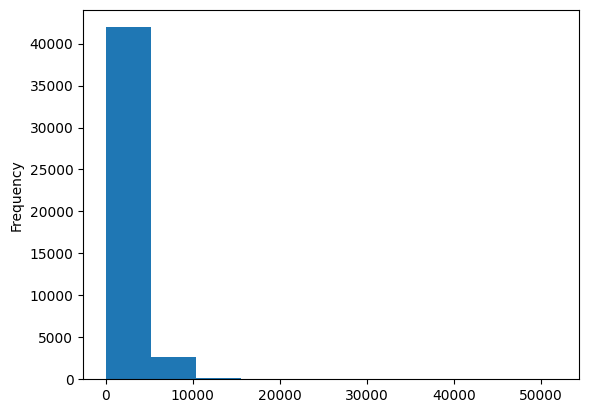

In [ ]:
# Explore data
train_data['text_length'] = train_data['content'].apply(len) # นับความยาวตัวอักษร
print("Mean overview length: ", train_data['text_length'].mean()) # ค่าเฉลี่ยความยาวตัวอักษร
print("Min overview length: ", train_data['text_length'].min()) # ความยาวตัวอักษรน้อยสุด
print("Max overview length: ", train_data['text_length'].max()) # ความยาวตัวอักษรมากสุด
train_data['text_length'].plot.hist() # plot Histrogram

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44900 entries, 0 to 44899
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        44900 non-null  object
 1   content      44900 non-null  object
 2   is_fake      44900 non-null  object
 3   text_length  44900 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.4+ MB


In [ ]:
text = list(train_data[train_data["is_fake"] == 'True'].content.values) # สร้าง list content ข่าว
text[:5]

["If anyone thought the man who s been attacked by the left for most of his adult life, was going to roll over and play dead, as the Democrats and their allies in the entertainment industry come at him with a coordinated character assassination attempt, they were sadly mistaken.Breitbart   The U.S. Senate campaign of Judge Roy Moore is firing back at Jimmy Kimmel and his paid trickster Rich Barbieri also known as  Jake Byrd for disrupting a worship service at which Moore spoke here on Wednesday night. Jimmy Kimmel and the  Hollywood elite  cross the line when they invade our Churches under a disguise and attempt to make a mockery of our worship services,  Drew Messer, a senior adviser to Moore, told Breitbart News on Thursday morning after the incident at the church on Wednesday night.On Wednesday evening, after the pastor of Magnolia Springs Baptist Church here in Theodore, Alabama, just outside Mobile warned attendees of a worship service at which Moore was speaking multiple times th

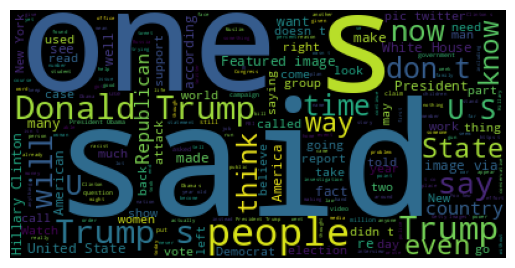

In [ ]:
# สร้าง Word cloud
wordcloud = WordCloud(stopwords=STOPWORDS).generate(str(text)) # ตัดคำพวก a, the,... เพื่อ show คำที่มีความหมาย
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Mean overview length:  2525.155845932818
Min overview length:  101
Max overview length:  49705


<Axes: ylabel='Frequency'>

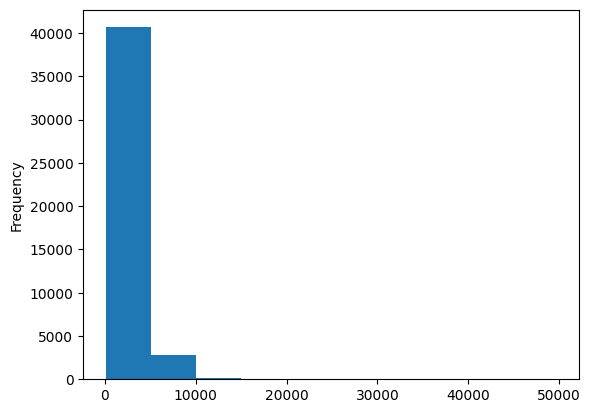

In [ ]:
train_data = train_data.loc[train_data['text_length'] > 100] # filter เฉพาะความยาวตัวอักษร > 50
train_data = train_data.loc[train_data['text_length'] < 50000] # filter เฉพาะความยาวตัวอักษร < 2000
print("Mean overview length: ", train_data['text_length'].mean()) # ค่าเฉลี่ยความยาวตัวอักษร
print("Min overview length: ", train_data['text_length'].min()) # ความยาวตัวอักษรน้อยสุด
print("Max overview length: ", train_data['text_length'].max()) # ความยาวตัวอักษรมากสุด
train_data['text_length'].plot.hist()

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43851 entries, 0 to 44899
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        43851 non-null  object
 1   content      43851 non-null  object
 2   is_fake      43851 non-null  object
 3   text_length  43851 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


remove punctuation เครื่องหมายวรรคตอน

In [ ]:
# remove !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~
exclude = set(string.punctuation) # !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~
def remove_punctoation(row):
  row.content = ''.join(ch for ch in row.content if ch not in exclude)
  return row

In [ ]:
train_data = train_data.apply(remove_punctoation, axis = 1)

Lemmatisation

In [ ]:
lemmatizer = WordNetLemmatizer()
def lemmatize_text(row):
  row.content = " ".join(lemmatizer.lemmatize(word) for word in row.content.split())
  return row

In [ ]:
train_data = train_data.apply(lemmatize_text, axis = 1)

count vectorizer

In [ ]:
vectorizer = CountVectorizer(lowercase = True, stop_words='english', max_features= 2000)
count_vectors = vectorizer.fit_transform(train_data.content)

In [ ]:
count_vectors.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

TFIDF vectorizer

In [ ]:
TFIDF_vectorizer = TfidfVectorizer(lowercase = True, stop_words='english', max_features = 2000)
tfidf_vectors = TFIDF_vectorizer.fit_transform(train_data.content)

In [ ]:
tfidf_vectors.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Modeling

In [ ]:
X_count_train, X_count_test, y_count_train, y_count_test = train_test_split(count_vectors, list(train_data.is_fake), test_size=0.2, random_state=42)

In [ ]:
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(tfidf_vectors, list(train_data.is_fake), test_size=0.2, random_state=42)

In [ ]:
# MultinomialNB()
model = MultinomialNB() #เรียก Model MultinomialNB
model.fit(X_count_train, y_count_train) # fit data กับ Model
score_train = model.score(X_count_train, y_count_train) # train
score_test = model.score(X_count_test, y_count_test) # test
print("\nTrain set score:", score_train)
print("Test set score:", score_test)


Train set score: 0.9405074116305587
Test set score: 0.9417398244213887


In [ ]:
y_pred = model.predict(X_count_test)

In [ ]:
# DecisionTreeClassifier()
dt_model = DecisionTreeClassifier(max_depth=15, random_state=0)
dt_model.fit(X_tfidf_train, y_tfidf_train)
score_train = dt_model.score(X_tfidf_train, y_tfidf_train)
score_test = dt_model.score(X_tfidf_test, y_tfidf_test)
print("\nTrain set score:", score_train)
print("Test set score:", score_test)


Train set score: 0.9969783352337515
Test set score: 0.9940713715653859


In [ ]:
y_dt_pred = dt_model.predict(X_tfidf_test)

Evaluating

In [ ]:
# evalute y_pred of MultinomialNB()
confusion_matrix(y_count_test, y_pred)

array([[3978,  239],
       [ 272, 4282]])

In [ ]:
print(classification_report(y_count_test, y_pred))

              precision    recall  f1-score   support

       False       0.94      0.94      0.94      4217
        True       0.95      0.94      0.94      4554

    accuracy                           0.94      8771
   macro avg       0.94      0.94      0.94      8771
weighted avg       0.94      0.94      0.94      8771



In [ ]:
# evalute y_pred(y_dt_pred) of DecisionTreeClassifier()
confusion_matrix(y_count_test, y_dt_pred)

array([[4200,   17],
       [  35, 4519]])

In [ ]:
print(classification_report(y_count_test, y_dt_pred))

              precision    recall  f1-score   support

       False       0.99      1.00      0.99      4217
        True       1.00      0.99      0.99      4554

    accuracy                           0.99      8771
   macro avg       0.99      0.99      0.99      8771
weighted avg       0.99      0.99      0.99      8771



In [ ]:
# หาข่าวในเน็ต
inference_l = []
# https://www.bbc.com/news/technology-67366311
T1 = "Meta will require political advertisers to flag when they have used AI or digital manipulation in adverts on Facebook and Instagram.The social media company already has policies on using deepfakes in place, but says this goes a step further.From January, adverts related to politics, elections or social issues will have to declare any digitally altered image or video.The worldwide policy will be moderated by a mix of human and AI fact checkers.In an announcement, Meta said this would include changing what somebody has said in a video, altering images or footage of real events, and depicting real-looking people who do not exist.Users will be notified when adverts have been marked as being digitally changed. Meta told the BBC that it would add this information to the ad but didn't go into detail on how it would be presented.Advertisers do not have to declare when small changes have been made, such as cropping or colour correction, 'unless such changes are consequential or material to the claim, assertion, or issue raised in the ad'.Meta already has policies for all users - not just advertisers - about using deepfakes in videos.Deepfakes are removed if they 'would likely mislead an average person to believe a subject of the video said words that they did not say'.The new rules require adverts relating to politics, elections or social issues to disclose any kind of digital alteration, whether done by a human or AI, before the ad goes live on Facebook or Instagram.Meta's other social media platform, Threads, follows the same policies as Instagram.It says that if advertisers do not declare this when they upload adverts, 'we will reject the ad and repeated failure to disclose may result in penalties against the advertiser.'Google recently announced a similar policy on its platforms. TikTok does not allow any political advertising,General elections are expected in 2024 in some of the world's biggest democracies, including India, Indonesia, the US and the UK.Russia, South Africa and the EU also have elections scheduled for next year.Deepfakes - where AI is used to changed what someone says or does in a video - are a growing concern in politics.In March, a fake picture of former US President Donald Trump falsely showing him being arrested was shared on social media. The image was created by AI tools.The same month, a deepfake video circulated of Ukrainian President Volodymyr Zelensky talking of surrendering to Russia.However in July, false claims that a video of US President Joe Biden was a deepfake were debunked, with the video proven to be authentic."
inference_l.append({'title': 'Meta requires political advertisers to mark when deepfakes used',
                     'content': T1,
                     'is_fake': True})

# https://www.bbc.com/news/articles/c9vnyl2jnpjo
T2 = "US intelligence agencies say 'Russian influence actors are behind a suspected fake video of a Haitian man who claims to have voted “multiple times” in Georgia.The 20-second video, which has been viewed hundreds of thousands of times on X and other social networks, shows two men in a car claiming to be Haitian.One says they obtained US citizenship within six months of arriving and have voted for Kamala Harris in Gwinnett and Fulton counties in Georgia. They encourage other Haitians to come to the United States.The BBC has found clear indications, including false addresses and stock photos, which indicate the video is a fake.In a statement, three US security agencies said that the video 'falsely depicted individuals claiming to be from Haiti' and was made by 'Russian influence actors"'.'"This Russian activity is part of Moscow’s broader effort to raise unfounded questions about the integrity of the US election and stoke divisions among Americans,' said the joint statement from the Office of the Director of National Intelligence, the Federal Bureau of Investigation, and the Cybersecurity and Infrastructure Security Agency.The Russian embassy in the US said the accusations were 'baseless', adding that Russia 'has not and does not interfere in the internal affairs of other countries' in a statement on Telegram.But researchers at Clemson University said that the video bore the hallmarks of a Russian disinformation operation known as Storm-1516.“This narrative is consistent with what we’ve seen from Storm-1516, especially in recent weeks since they’ve turned their focus squarely on the US election,” said Clemson’s Darren Linvill.“We should absolutely not be surprised that they are focused on undermining the integrity of the US election.“This is consistent with Russian strategy over the last two election cycles. Linvill said the narrative focus, style and production of the video match previous efforts by the Russian operation, which is linked, Clemson researchers say, to an organisation called the Russian Foundation to Battle Injustice.The organisation was founded by Yevgeny Prigozhin, the mercenary leader who headed the Wagner Group until he launched a rebellion against Moscow and died in a plane crash.Georgia s chief elections official, Secretary of State Brad Raffensperger, said that the clip is fake and part of a disinformation effort. He asked X owner Elon Musk and owners of other social media platforms to remove the video.One man in the clip shows multiple driving licences to the camera, presumably as proof of identity. BBC Verify took screenshots of these and enhanced the images to be able to read the details on them.The addresses on two of the licences match up to a business site and a location in the middle of a road near a petrol station - not residential addresses.A reverse image search of the photograph on one of the licences showed it was a stock image of a man originally produced by a production company in South Africa.US intelligence agencies said last week that a video purporting to show a poll worker destroying mail-in ballots marked for Donald Trump in Pennsylvania was manufactured and amplified by Russians."
inference_l.append({'title': 'US officials say Russians faked "Haitian voters" video',
                     'content': T2,
                     'is_fake': True})


inference_ds = pd.DataFrame(inference_l)

In [ ]:
inference_ds

,title,content,is_fake
0,Meta requires political advertisers to mark wh...,Meta will require political advertisers to fla...,True
1,"US officials say Russians faked ""Haitian voter...",US intelligence agencies say 'Russian influenc...,True


In [ ]:
# apply ข่าวใหม่เพื่อทำการ predict
inference_ds = inference_ds.apply(remove_punctoation, axis = 1) # remove !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~
inference_ds = inference_ds.apply(lemmatize_text, axis = 1)
inference_vectors = vectorizer.transform(inference_ds.content)

In [ ]:
# use model MultinomialNB() for predict
model.predict(inference_vectors)

array(['True', 'True'], dtype='<U5')

In [ ]:
# use model DecisionTreeClassifier() for predict
dt_model.predict(inference_vectors)

array(['True', 'True'], dtype='<U5')